# <font color='blue'>Tarea 4. </font>
### <font color='red'>08 de enero de 2026</font>
### Andrés Padrón Quintana 
### <font color='green'>Módulo 5. DATA SCIENCE AND MACHINE LEARNING APPLIED TO FINANCIAL MARKETS </font>

1. Investigar los únicos cinco optimizadares que no vimos en clase: 

https://keras.io/api/optimizers/ftrl/

https://keras.io/api/optimizers/adafactor/

https://keras.io/api/optimizers/lion/

https://keras.io/api/optimizers/adamw/

https://keras.io/api/optimizers/loss_scale_optimizer/


- **FTRL (Follow-The-Regularized-Leader)**

Es un optimizador pensado para modelos “shallow” (una o dos capas) con muchísimas variables y muy dispersas (sparse). Combina actualizaciones tipo online learning con regularización (L1/L2), por eso se usa mucho en problemas tipo CTR y features one-hot grandes.

- **Adafactor**

Es un optimizador adaptativo similar en espíritu a Adam, pero diseñado para usar mucho menos memoria: en vez de guardar el historial completo (segundo momento) para cada parámetro, guarda una aproximación “factorizada”. Es muy común en NLP/Transformers cuando el modelo es enorme.

- **Lion**

Es un método tipo SGD que usa el signo (sign) para controlar el tamaño/dirección de la actualización y mantiene básicamente solo momentum (no segundos momentos como Adam). Eso lo vuelve más eficiente en memoria y, según sus autores, suele mejorar relativo a Adam al crecer el batch size.

- **AdamW**

Es Adam, pero con weight decay desacoplado: la penalización a los pesos se aplica de forma separada a la actualización por gradiente, en lugar de “mezclarse” como L2 dentro del gradiente. En práctica, suele dar mejor regularización/generalización que Adam con L2 “clásico”.

- **LossScaleOptimizer**

No es un optimizador “nuevo” de actualizaciones, sino un wrapper: envuelve a otro optimizador y escala la loss para evitar underflow cuando entrenas en float16 (mixed precision). Si detecta gradientes no finitos baja la escala y puede saltarse el paso; si todo va bien por cierto tiempo, la aumenta.

2. Replicar el ejercicio anterior
n_epochs=8
n_folds=3
De los resultados de los 10 métodos + (5 tarea) de arriba en nuestra base de Fashion, ¿cuáles fueron los mejores y peores? y ¿por qué creen que haya pasado eso?
n_epochs=8
n_folds=3
¿En donde parece que hay evidencia de sobre ajuste en las Curvas de Aprendizaje?

In [1]:
# Instalamos paquetes

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold

import tensorflow as tf
print("TF version:", tf.__version__)
print("Eager enabled?:", tf.executing_eagerly())


2026-01-07 18:35:11.549440: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TF version: 2.16.2
Eager enabled?: True


In [2]:
K = tf.keras
print("Keras (tf.keras) listo")


Keras (tf.keras) listo


In [3]:
def cargar_fashion_mnist():
    (trainX, trainY), (testX, testY) = K.datasets.fashion_mnist.load_data()

    trainX = trainX.reshape((-1, 28, 28, 1)).astype("float32") / 255.0
    testX  = testX.reshape((-1, 28, 28, 1)).astype("float32") / 255.0

    trainY = K.utils.to_categorical(trainY, 10).astype("float32")
    testY  = K.utils.to_categorical(testY, 10).astype("float32")

    
    trainX = np.asarray(trainX, dtype=np.float32)
    trainY = np.asarray(trainY, dtype=np.float32)
    testX  = np.asarray(testX, dtype=np.float32)
    testY  = np.asarray(testY, dtype=np.float32)

    return trainX, trainY, testX, testY

trainX, trainY, testX, testY = cargar_fashion_mnist()
trainX.shape, trainY.shape


((60000, 28, 28, 1), (60000, 10))

In [4]:
opt_factory = None  # Aquí guardamos la función que crea el optimizador

def define_model():
    model = K.models.Sequential([
        K.layers.Input(shape=(28, 28, 1)),
        K.layers.Flatten(),
        K.layers.Dense(350, activation="relu"),
        K.layers.Dense(100, activation="relu"),
        K.layers.Dense(10, activation="softmax")
    ])

    # Optimizador NUEVO para este modelo
    optimizer = opt_factory()

    model.compile(
        optimizer=optimizer,
        loss="categorical_crossentropy",
        metrics=["accuracy"],
        run_eagerly=True
    )
    return model


In [5]:
def evaluar_kfold(trainX, trainY, n_folds=3, n_epochs=8, batch_size=128, verbose=0):
    scores, histories = [], []
    kfold = KFold(n_splits=n_folds, shuffle=True, random_state=1)

    for train_ix, val_ix in kfold.split(trainX):
        tf.keras.backend.clear_session()

        model = define_model()

        X_tr, y_tr = trainX[train_ix], trainY[train_ix]
        X_va, y_va = trainX[val_ix],  trainY[val_ix]

        history = model.fit(
            X_tr, y_tr,
            epochs=n_epochs,
            batch_size=batch_size,
            validation_data=(X_va, y_va),
            verbose=verbose
        )

        _, acc = model.evaluate(X_va, y_va, verbose=0)
        scores.append(acc)
        histories.append(history)

    return scores, histories

def resumen(scores):
    return float(np.mean(scores)), float(np.std(scores))


In [6]:
optimizadores = [
    ("SGD",      lambda: K.optimizers.SGD(learning_rate=0.01)),
    ("Momentum", lambda: K.optimizers.SGD(learning_rate=0.01, momentum=0.9)),
    ("NAG",      lambda: K.optimizers.SGD(learning_rate=0.01, momentum=0.9, nesterov=True)),
    ("Adagrad",  lambda: K.optimizers.Adagrad(learning_rate=0.01)),
    ("RMSprop",  lambda: K.optimizers.RMSprop(learning_rate=0.01)),
    ("Adadelta", lambda: K.optimizers.Adadelta(learning_rate=0.01)),
    ("Adam",     lambda: K.optimizers.Adam(learning_rate=0.01)),
    ("Adamax",   lambda: K.optimizers.Adamax(learning_rate=0.01)),
    ("Nadam",    lambda: K.optimizers.Nadam(learning_rate=0.01)),
    ("AMSGrad",  lambda: K.optimizers.Adam(learning_rate=0.01, amsgrad=True)),
    ("FTRL",     lambda: K.optimizers.Ftrl(learning_rate=0.01)),
    ("Adafactor",lambda: K.optimizers.Adafactor(learning_rate=0.01)),
    ("Lion",     lambda: K.optimizers.Lion(learning_rate=0.01)),
    ("AdamW",    lambda: K.optimizers.AdamW(learning_rate=0.01, weight_decay=1e-4)),
]

def loss_scale_factory():
    # wrapper: devuelve un optimizador nuevo cada vez
    base = K.optimizers.Adam(learning_rate=0.01)
    return K.mixed_precision.LossScaleOptimizer(base)


try:
    _ = loss_scale_factory()
    optimizadores.append(("Adam+LossScale", loss_scale_factory))
except Exception:
    pass


resultados = []
historias_por_opt = {}

for nombre, factory in optimizadores:
    print(f"\n=== Corriendo: {nombre} ===")
    try:
        opt_factory = factory  # guardamos el factory global para que define_model lo use

        scores, histories = evaluar_kfold(trainX, trainY, n_folds=3, n_epochs=8, batch_size=128, verbose=0)
        mu, sd = resumen(scores)

        resultados.append({"Optimizador": nombre, "Acc_mean": mu, "Acc_std": sd})
        historias_por_opt[nombre] = histories

        print(f"[OK] {nombre}: mean={mu:.4f} std={sd:.4f}")

    except Exception as e:
        print(f"[ERROR] {nombre}: {type(e).__name__}: {e}")
        continue

# Tabla
if len(resultados) == 0:
    print("No se generaron resultados (todos fallaron). Revisa los errores arriba.")
else:
    tabla = pd.DataFrame(resultados).sort_values("Acc_mean", ascending=False).reset_index(drop=True)
    tabla



=== Corriendo: SGD ===
[OK] SGD: mean=0.8344 std=0.0040

=== Corriendo: Momentum ===
[OK] Momentum: mean=0.8741 std=0.0028

=== Corriendo: NAG ===
[OK] NAG: mean=0.8767 std=0.0028

=== Corriendo: Adagrad ===
[OK] Adagrad: mean=0.8560 std=0.0046

=== Corriendo: RMSprop ===
[OK] RMSprop: mean=0.8431 std=0.0177

=== Corriendo: Adadelta ===
[OK] Adadelta: mean=0.8082 std=0.0005

=== Corriendo: Adam ===
[OK] Adam: mean=0.8724 std=0.0034

=== Corriendo: Adamax ===
[OK] Adamax: mean=0.8801 std=0.0020

=== Corriendo: Nadam ===
[OK] Nadam: mean=0.8713 std=0.0025

=== Corriendo: AMSGrad ===
[OK] AMSGrad: mean=0.8711 std=0.0080

=== Corriendo: FTRL ===
[OK] FTRL: mean=0.1363 std=0.0501

=== Corriendo: Adafactor ===
[OK] Adafactor: mean=0.1000 std=0.0029

=== Corriendo: Lion ===
[OK] Lion: mean=0.2762 std=0.0406

=== Corriendo: AdamW ===
[OK] AdamW: mean=0.8612 std=0.0151

=== Corriendo: Adam+LossScale ===
[OK] Adam+LossScale: mean=0.8677 std=0.0050


**Mejores y peores
Mejores (top 3)**

**Adamax:** mean = 0.8801, std = 0.0020

**NAG:** mean = 0.8767, std = 0.0028

**Momentum:** mean = 0.8741, std = 0.0028


**Peores (bottom 3)**

**Adafactor:** mean = 0.1000, std = 0.0029

**FTRL:** mean = 0.1363, std = 0.0501

**Lion:** mean = 0.2762, std = 0.0406

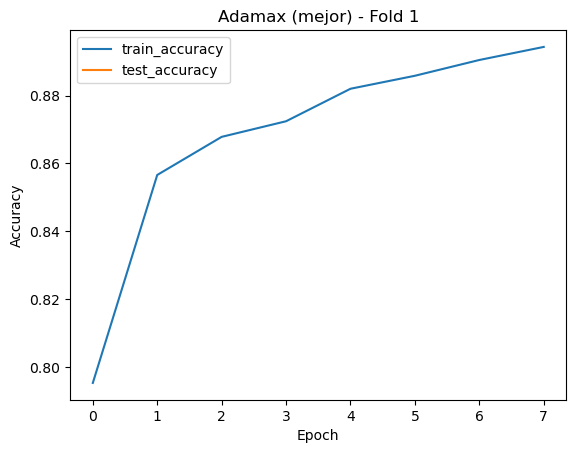

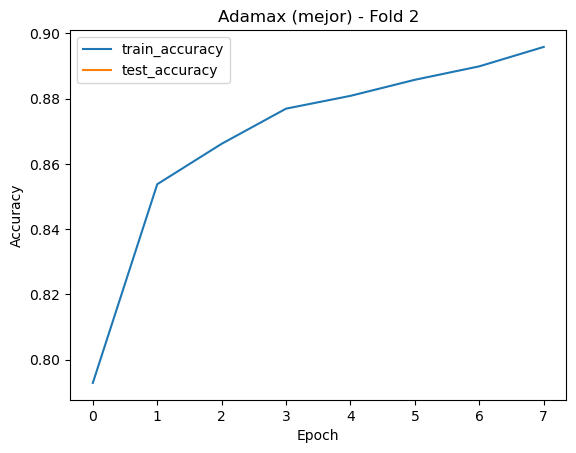

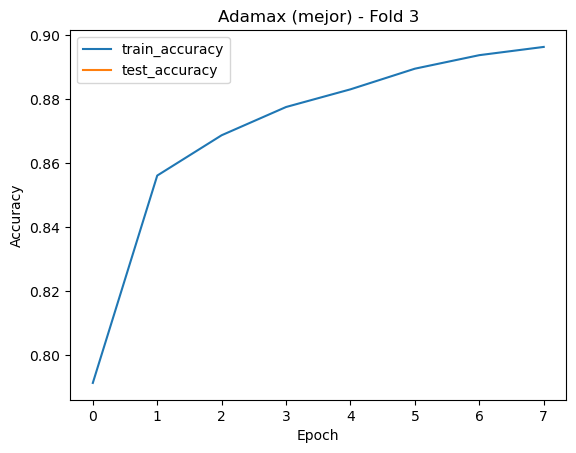

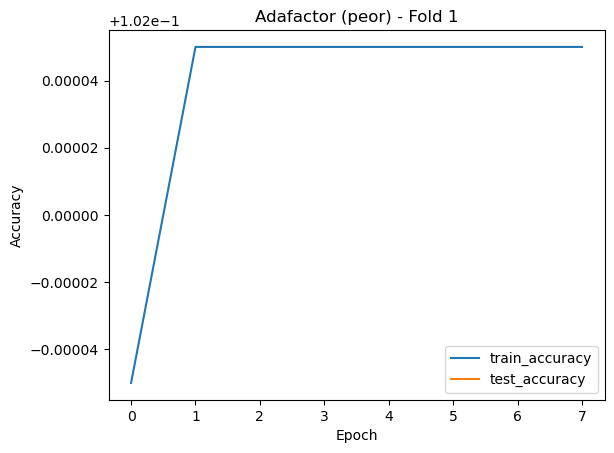

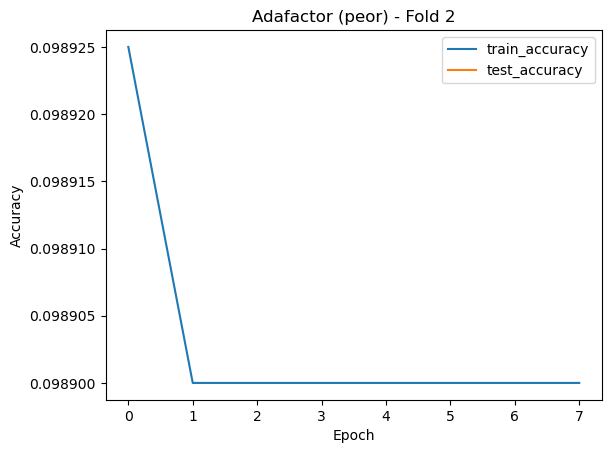

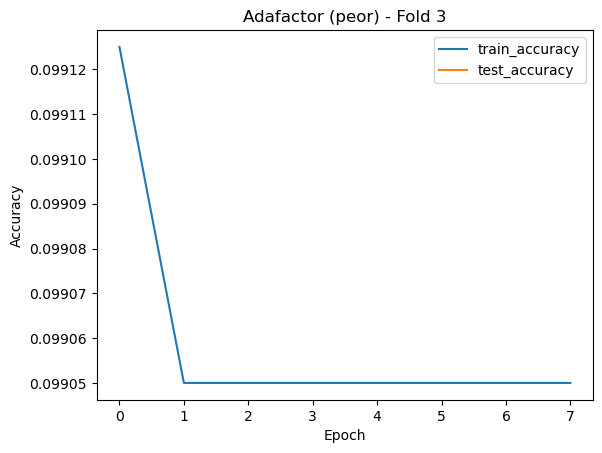

In [14]:
plot_curvas_por_opt(historias_por_opt["Adamax"], "Adamax (mejor)")
plot_curvas_por_opt(historias_por_opt["Adafactor"], "Adafactor (peor)")


**¿Por qué pasó eso?**

**Adamax / Momentum / NAG** salen arriba porque este problema (Fashion-MNIST con un MLP) se beneficia de métodos que aceleran la convergencia y/o son robustos a la escala del gradiente.

**Momentum y NAG** suavizan y anticipan la dirección de descenso, reduciendo zig-zag y avanzando más estable.

**Adamax** (variante de Adam basada en norma infinito) suele comportarse bien con gradientes ruidosos y converge rápido con hiperparámetros razonables.

**Adafactor, FTRL y Lion** te salieron muy abajo principalmente por desajuste de contexto e hiperparámetros:

**FTRL** está pensado sobre todo para escenarios con features muy dispersas (sparse) y modelos tipo lineales/embeddings; aquí tienes una red densa con ReLU, por lo que con los mismos defaults/learning rate puede aprender muy mal. Además tu std enorme (0.0501) indica inestabilidad entre folds.

**Adafactor** está diseñado para ser ahorrador de memoria y se usa mucho en modelos grandes (p. ej., Transformers). En un MLP pequeño puede requerir tuning fino (learning rate, factorización, etc.). 

**Lion** suele funcionar bien, pero es muy sensible al learning rate / weight decay; con el learning rate que usaste (igual al resto) se ve que no quedó en un régimen estable de entrenamiento (mean baja y std alta).

**AdamW** quedó razonable (0.8612) pero no top: el weight decay puede ayudar a generalizar, pero con solo 8 épocas y sin ajustar weight_decay/lr, no necesariamente supera a Adamax/NAG.

**Adam+LossScale** (0.8677) no gana porque el loss scaling no es para mejorar accuracy, sino para estabilidad numérica cuando entrenas en mixed precision (float16). 

**¿Dónde hay evidencia de sobreajuste en las curvas?****


In [11]:
import matplotlib.pyplot as plt
import numpy as np

def plot_curvas_por_opt(histories, titulo):
    """
    histories: lista de objetos History (uno por fold)
    """
    for i, h in enumerate(histories, 1):
        acc = h.history.get("accuracy", [])
        val = h.history.get("test_accuracy", [])

        plt.figure()
        plt.plot(acc, label="train_accuracy")
        plt.plot(val, label="test_accuracy")
        plt.title(f"{titulo} - Fold {i}")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.legend()
        plt.show()


In [27]:
def plot_promedio_folds(histories, titulo):
    accs = np.array([h.history["accuracy"] for h in histories])
    vals = np.array([h.history["val_accuracy"] for h in histories])

    acc_mean = accs.mean(axis=0)
    val_mean = vals.mean(axis=0)

    plt.figure()
    plt.plot(acc_mean, label="train_accuracy (mean)")
    plt.plot(val_mean, label="test_accuracy (mean)")
    plt.title(titulo)
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()


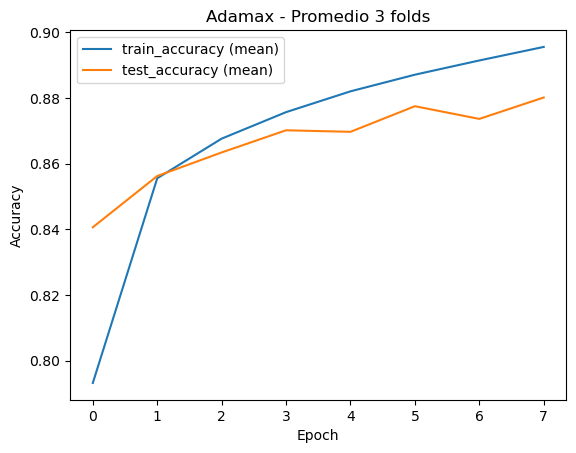

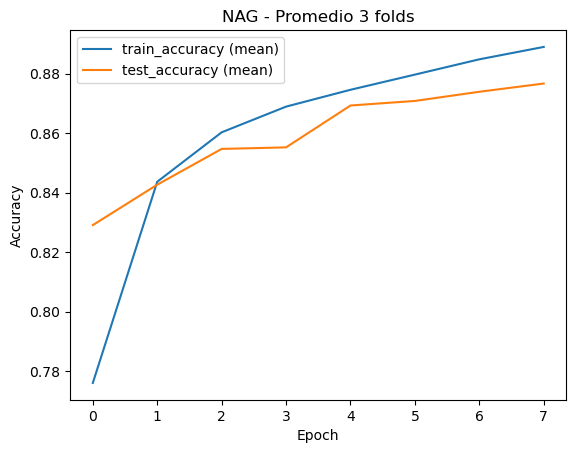

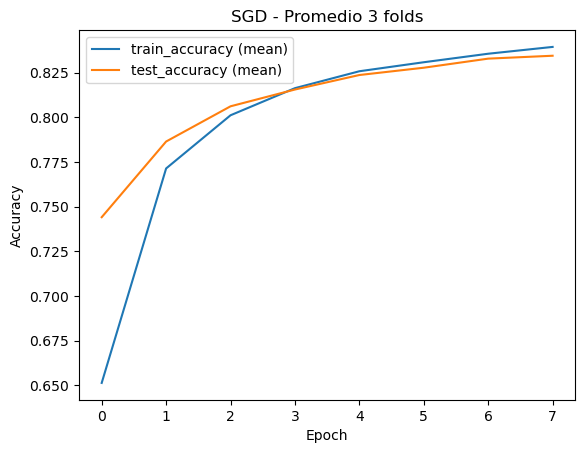

In [28]:
plot_promedio_folds(historias_por_opt["Adamax"], "Adamax - Promedio 3 folds")
plot_promedio_folds(historias_por_opt["NAG"], "NAG - Promedio 3 folds")
plot_promedio_folds(historias_por_opt["SGD"], "SGD - Promedio 3 folds")


En Adamax se observa una brecha creciente train–val hacia las últimas épocas y una ligera caída de la validación alrededor de los epochs 5–6, lo que sugiere inicio de sobreajuste (aunque moderado, porque la validación se recupera al final)

Con NAG las curvas de entrenamiento y validación crecen de forma paralela y la validación no presenta caídas, por lo que hay poca evidencia de sobreajuste en las 8 épocas; el comportamiento sugiere buena generalización

En SGD train y val se mantienen muy cercanas durante todo el entrenamiento, lo que indica muy poca evidencia de sobreajuste; sin embargo, la convergencia es más lenta y su accuracy final queda por debajo de Adamax y NAG en 8 épocas

In [26]:
def epoch_mejor_val(histories):
    vals = np.array([h.history["val_accuracy"] for h in histories])
    val_mean = vals.mean(axis=0)
    best_epoch = int(np.argmax(val_mean)) + 1  # +1 para contar epochs desde 1
    best_val = float(np.max(val_mean))
    last_val = float(val_mean[-1])
    return best_epoch, best_val, last_val

best_epoch, best_val, last_val = epoch_mejor_val(historias_por_opt["Adamax"])
print("Adamax -> mejor epoch (val):", best_epoch, "best_val:", best_val, "val_last:", last_val)


Adamax -> mejor epoch (val): 8 best_val: 0.8801166812578837 val_last: 0.8801166812578837
